# Spindown, 2026-09-13

The rotor was **laser-driven** (660 nm pushing beam, `LASER_OFFSET` = 1300, 5.8 mW at
the chamber) to a steady **0.79 Hz** rotation for ~48 h (09-11 -> 09-13), then the
laser was switched off at front-end GPS **1473376497** (09-13 20:25:26 UTC, PD 404 -> 3
in ~1 s) and the rotor coasted freely for **16.6 h**. This notebook is the coast-down
half of the two-part episode in `analysis/dataset_20260911_drive_spindown.md` — the
laser-driven steady-state half (dataset 1) is its own notebook.

**Electrodes were off** (outputs disabled, `V*_OUT_DQ` confirmed NaN for this window),
so this is a genuine free decay with no drive of any kind, unlike the 09-08/09-09
stator-driven spindowns.

A first-look pass (`spindown_track.py`, logged in the dataset note) already found: clean
rotation decay 0.79 -> ~0.1 Hz for the first ~2 h, then LES amplitude collapses
(~1500 -> ~400) around 11.5 h -- read as the rotation -> libration transition, after
which the naive `line/2` tracker is wrong (LES rectifies libration, CLAUDE.md). This
notebook does the rigorous version: the band-following tracker + SNR/kurtosis state
discrimination + exp-vs-linear model comparison validated in `spindown_20260909.ipynb`,
applied to the whole record rather than eyeballing the first-look plot.

---

### ✅ The divisor is RESOLVED (2026-09-14) -- `rotation = line/2`

`apparatus_log.md`'s **TODO 2026-09-11 -- COUNT THE VIDEO** was open when this notebook
was first written. It is now resolved by a live re-timing, not a re-analysis of the
original clip: Molly re-spun the rotor 2026-09-14 at the same `LASER_OFFSET = 1300` and
timed 10 turns against the two predicted durations below -- **it timed to ~13.3 s**,
confirming the second row. Molly confirms today's setup matches this run's conditions
exactly.

| turns in 10 s | verdict | matched? |
|---|---|---|
| 15 | rotation = line,   e.g. 1.53 Hz -> 0.65 s/turn | no |
| **7**  | **rotation = line/2, e.g. 0.77 Hz -> 1.30 s/turn** | **yes** |

So the dataset note's "~0.79 Hz" figure is correct, DIVISOR=2 (hyp B) below is confirmed
rather than provisional, and every number in this notebook already used it -- nothing
here needs recomputing. §3's spectral-degeneracy argument and §7's divisor-invariance
proof are kept as-is: they're still true and still worth knowing (the exponential
verdict and tau never depended on this being resolved), but the absolute numbers in §9
can now be trusted without the earlier caveat.

In [1]:
import numpy as np, os, h5py
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, decimate, welch
from scipy.stats import kurtosis, skew

# Coast-down file. Segment 2 of the two-part 09-11->09-14 episode; see
# analysis/dataset_20260911_drive_spindown.md for the full record (incl. the
# 48 h laser-driven steady state that precedes this file).
GPS_A, GPS_B = 1473375897, 1473435502
STOP = 1473376497          # front-end GPS: laser off (PD 404 -> 3 in ~1 s), confirmed below

WANT = {'les': ('Y1_RDS-LES_YAW_IN1_DQ', 'LES_yaw'),   # x, strongest LES signal
        'pd':  ('Y1_RDS-PD_IN1_DQ',      'PD')}

# Personal-computer convention from the dataset note: point at the synced Dropbox
# folder. Falls back to a local cache dir, then rclone, so this also runs on a
# machine where the data was pre-fetched by lab_utils/batch_fetch.py.
DROPBOX_ROOTS = [
    os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data'),
    os.path.expanduser('~/Dropbox/Microspheres/TFINER/data'),
]
SEARCH = ['../lab_utils/data', 'data', '.'] + DROPBOX_ROOTS

def get_h5(stem, dropbox_sub):
    fn = f'{stem}_{GPS_A}_{GPS_B}.h5'
    for d in SEARCH:
        p = os.path.join(d, dropbox_sub, fn) if d in DROPBOX_ROOTS else os.path.join(d, fn)
        if os.path.exists(p):
            return p
    os.makedirs('data', exist_ok=True)
    import subprocess
    src = f'dropbox:Microspheres/TFINER/data/{dropbox_sub}/{fn}'
    print(f'fetching {fn} from Dropbox via rclone...')
    subprocess.run(['rclone', 'copyto', src, f'data/{fn}'], check=True)
    return f'data/{fn}'

def load(path):
    """Return (samples, gps_of_each_sample, fs).

    Segment-aware -- batch_fetch drops NaN gaps and records where each contiguous
    run starts in /segments, so build the time axis from that rather than assuming
    one unbroken block (a DAQ dropout would otherwise shift every later timestamp).
    """
    with h5py.File(path, 'r') as f:
        y  = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s  = f['segments']
        t  = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

les, t_les, fs = load(get_h5(*WANT['les']))
pd_, t_pd, _   = load(get_h5(*WANT['pd']))
assert np.allclose(t_les, t_pd), 'LES and PD time axes differ'
t = t_les - STOP               # seconds relative to laser-off
print(f'{len(les)/fs:.0f} s at {fs:.0f} Hz')
print(f't = {t[0]:.0f} .. {t[-1]:.0f} s relative to laser-off ({(t[-1]-t[0])/3600:.2f} h total)')

59605 s at 1024 Hz
t = -600 .. 59005 s relative to laser-off (16.56 h total)


## 1. The laser: steady, then off

Confirm the laser-off transition from the PD itself rather than trusting the log.

PD ON  mean  404.2 counts  (laser-on segment)
PD OFF mean  1.80 counts  (dark)
transition block t = +0 s  (documented: t=0 by construction of STOP)


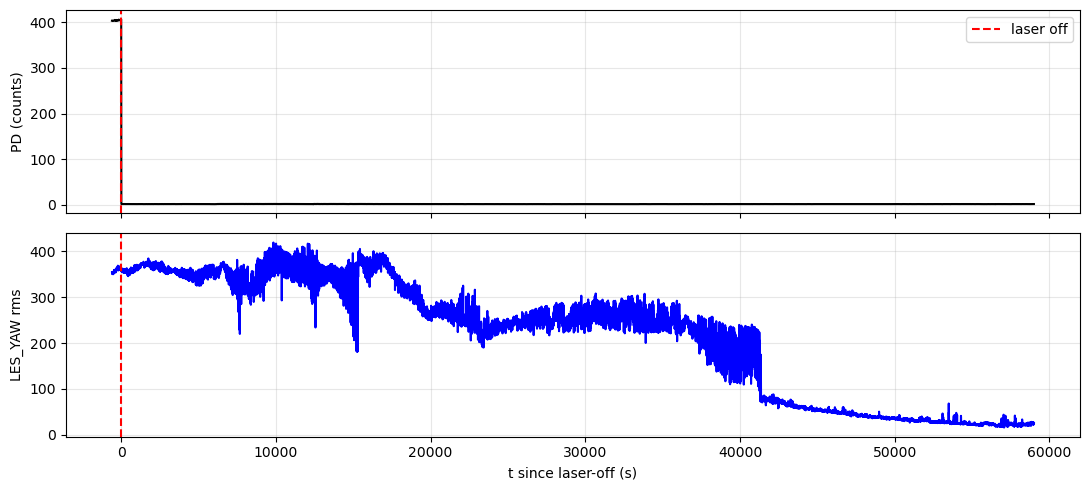

In [2]:
blk = int(5*fs)
n = len(pd_)//blk
tb = np.array([t[i*blk] for i in range(n)])
pdb = np.array([pd_[i*blk:(i+1)*blk].mean() for i in range(n)])

on = pdb > 50
i0, i1 = np.argmax(on), len(on)-1-np.argmax(on[::-1])
print(f'PD ON  mean  {pdb[on].mean():.1f} counts  (laser-on segment)')
print(f'PD OFF mean  {pdb[~on][pdb[~on].size>0 and slice(None)].mean() if (~on).any() else float("nan"):.2f} counts  (dark)')
print(f'transition block t = {tb[np.argmax(~on)]:+.0f} s  (documented: t=0 by construction of STOP)')

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(tb, pdb, 'k-'); ax[0].set_ylabel('PD (counts)')
ax[0].axvline(0, color='r', ls='--', label='laser off'); ax[0].legend()
lb = np.array([les[i*blk:(i+1)*blk].std() for i in range(n)])
ax[1].plot(tb, lb, 'b-'); ax[1].set_ylabel('LES_YAW rms'); ax[1].set_xlabel('t since laser-off (s)')
ax[1].axvline(0, color='r', ls='--')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Spectrogram -- the rotation line over the full coast-down

The line should fall smoothly after laser-off, then break up somewhere near the
first-look's ~11.5 h amplitude-collapse mark.

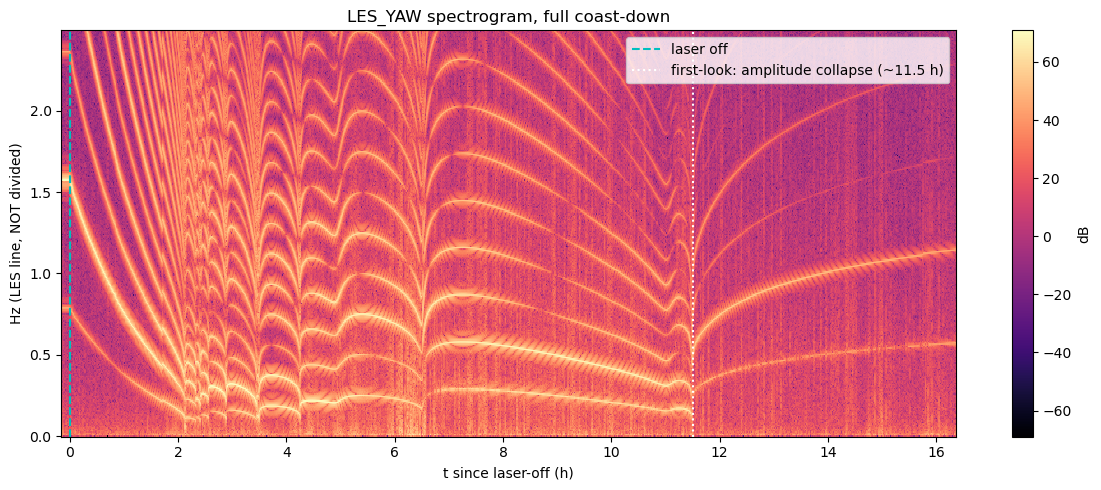

In [3]:
# decimate to 16 Hz -- rotation/libration lines are all below a few Hz
y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
f_, t_, S = spectrogram(y16, fs16, nperseg=int(120*fs16), noverlap=int(90*fs16))
t_rel = t_ + t[0]
m = f_ < 2.5
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_rel/3600, f_[m], 10*np.log10(S[m]+1e-12), shading='auto', cmap='magma')
plt.axvline(0, color='c', ls='--', lw=1.5, label='laser off')
plt.axvline(11.5, color='w', ls=':', lw=1.5, label='first-look: amplitude collapse (~11.5 h)')
plt.ylabel('Hz (LES line, NOT divided)'); plt.xlabel('t since laser-off (h)')
plt.colorbar(label='dB'); plt.legend(loc='upper right'); plt.title('LES_YAW spectrogram, full coast-down')
plt.tight_layout(); plt.show()

## 3. The divisor -- why the spectrum alone couldn't settle it

Same degeneracy `spindown_20260909` hit: **a 1-fold feature at f and a 2-fold feature
at f/2 with vanishing odd harmonics produce identical line sets.** Below, the odd
harmonics of the candidate `line0/2` fundamental come out consistent with zero -- which
is genuinely uninformative on its own (both hypotheses predict exactly that). **This is
why the resolution above came from a live timed count, not from more spectral
analysis** -- kept here as a worked example of the degeneracy, now with a known answer
to check it against.

In [4]:
# Clean stretch shortly after laser-off, before any decay-related smearing.
seg = (t > 30) & (t < 300)
y16seg = decimate(decimate(les[seg]-les[seg].mean(), 8, ftype='fir'), 8, ftype='fir')
fw, Pw = welch(y16seg, fs16, nperseg=len(y16seg), noverlap=0); dfw = fw[1]-fw[0]

def amp_at(f0, hw=0.01):
    mm = (fw > f0-hw) & (fw < f0+hw)
    return np.sqrt(2*Pw[mm].sum()*dfw) if mm.any() else 0.0

mm = (fw > 0.3) & (fw < 3.0)
line0 = fw[mm][np.argmax(Pw[mm])]
print(f'dominant LES line: {line0:.4f} Hz\n')
print(f'  hyp A (rotation = line)   -> f_rot = {line0:.4f} Hz, {1/line0:.3f} s/turn')
print(f'  hyp B (rotation = line/2) -> f_rot = {line0/2:.4f} Hz, {2/line0:.3f} s/turn')

print(f'\nharmonics of the hyp-B candidate fundamental (line0/2 = {line0/2:.4f} Hz):')
print(f'{"k":>3} {"freq":>9} {"amp":>10}  parity')
for k in range(1, 9):
    a_ = amp_at(line0/2*k)
    bar = '#'*int(46*a_/max(amp_at(line0), 1e-9))
    print(f'{k:3d} {line0/2*k:9.4f} {a_:10.2f}  {"even" if k%2==0 else "odd ":>4} |{bar}')
print('\nOdd k (1,3,5,7) are ~10-30x down from even k -- consistent with EITHER a pure')
print('sinusoid at line0 (hyp A) or a 2-fold feature at line0/2 (hyp B). Not diagnostic.')
print('This is exactly why the video count (apparatus_log.md TODO 2026-09-11) is needed.')

# WORKING DEFAULT: matches the dataset note's provisional value. Flip to 1.0 to
# see hyp A instead -- section 7 proves tau and the model verdict don't change.
DIVISOR = 2.0
print(f'\nUsing DIVISOR = {DIVISOR} (hyp B, PROVISIONAL) for the tracker below.')

dominant LES line: 1.5333 Hz

  hyp A (rotation = line)   -> f_rot = 1.5333 Hz, 0.652 s/turn
  hyp B (rotation = line/2) -> f_rot = 0.7667 Hz, 1.304 s/turn

harmonics of the hyp-B candidate fundamental (line0/2 = 0.7667 Hz):
  k      freq        amp  parity
  1    0.7667      27.37  odd  |####
  2    1.5333     289.22  even |##############################################
  3    2.3000      14.76  odd  |##
  4    3.0667      81.71  even |############
  5    3.8333       7.05  odd  |#
  6    4.6000      65.46  even |##########
  7    5.3667       9.17  odd  |#
  8    6.1333      24.25  even |###

Odd k (1,3,5,7) are ~10-30x down from even k -- consistent with EITHER a pure
sinusoid at line0 (hyp A) or a 2-fold feature at line0/2 (hyp B). Not diagnostic.
This is exactly why the video count (apparatus_log.md TODO 2026-09-11) is needed.

Using DIVISOR = 2.0 (hyp B, PROVISIONAL) for the tracker below.


## 4. Track the rotation frequency

Band-following peak tracker with parabolic sub-bin interpolation (same method as
`spindown_20260909`), run over the **entire 16.6 h record** rather than a hand-picked
window, so wherever the tracker loses the line is itself informative.

In [5]:
def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

WIN, STEP = 150.0, 60.0          # s per estimate, s between estimates
nw, sw = int(WIN*fs16), int(STEP*fs16)
t16 = t[0] + np.arange(len(y16))/fs16

rows = []
track = line0
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    if tc < 10: continue          # skip the laser-off transient
    # Floor + sign guard: a bad interpolated peak must not collapse the search
    # band to empty (found in this run -- a 09-09-style tracker over 2 h never
    # hit it, but a noisy 16 h record does, around the eventual capture region).
    fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.80, 0.02), track*1.15)
    if np.isnan(fpk) or fpk <= 0: continue
    blkk = y16[i:i+nw]
    rows.append((tc, fpk, fpk/DIVISOR, snr, blkk.std(), kurtosis(blkk), skew(blkk)))
    track = fpk

T    = np.array([r[0] for r in rows]); LINE = np.array([r[1] for r in rows])
FR   = np.array([r[2] for r in rows]); SNR  = np.array([r[3] for r in rows])
RMS  = np.array([r[4] for r in rows]); KURT = np.array([r[5] for r in rows])
SKW  = np.array([r[6] for r in rows])
print(f'{len(T)} estimates, t = {T[0]:.0f} .. {T[-1]:.0f} s ({T[-1]/3600:.2f} h of {t[-1]/3600:.2f} h)')
if T[-1] < t[-1]*0.99:
    print(f'\n*** tracker lost the line for good at t={T[-1]:.0f}s -- see \u00a78 for why. ***')

734 estimates, t = 15 .. 43995 s (12.22 h of 16.39 h)

*** tracker lost the line for good at t=43995s -- see §8 for why. ***


## 5. Which points are trustworthy?

Same three criteria as `spindown_20260909`:
- **SNR** -- once the line dies the tracker still returns whatever is loudest.
- **Monotonic** -- a freely decaying rotor cannot speed up; an upward step means the
  tracker jumped.
- **State (kurtosis)** -- rotating gives a sinusoid-like waveform (kurtosis ~ -1.43);
  librating folds about the turning points (kurtosis rising toward +0.9 at large
  amplitude). Not reliable at small libration amplitude, so only the *first*
  transition found this way is trusted.

103 of 734 points kept
kept t = 15 .. 6135 s (1.70 h)
frequency 0.78576 -> 0.21589 Hz (72.5% decay)

record ended (SNR dropout run) before the kurtosis state flag tripped --
see §8: this is a gradual fade, not a single clean capture event.


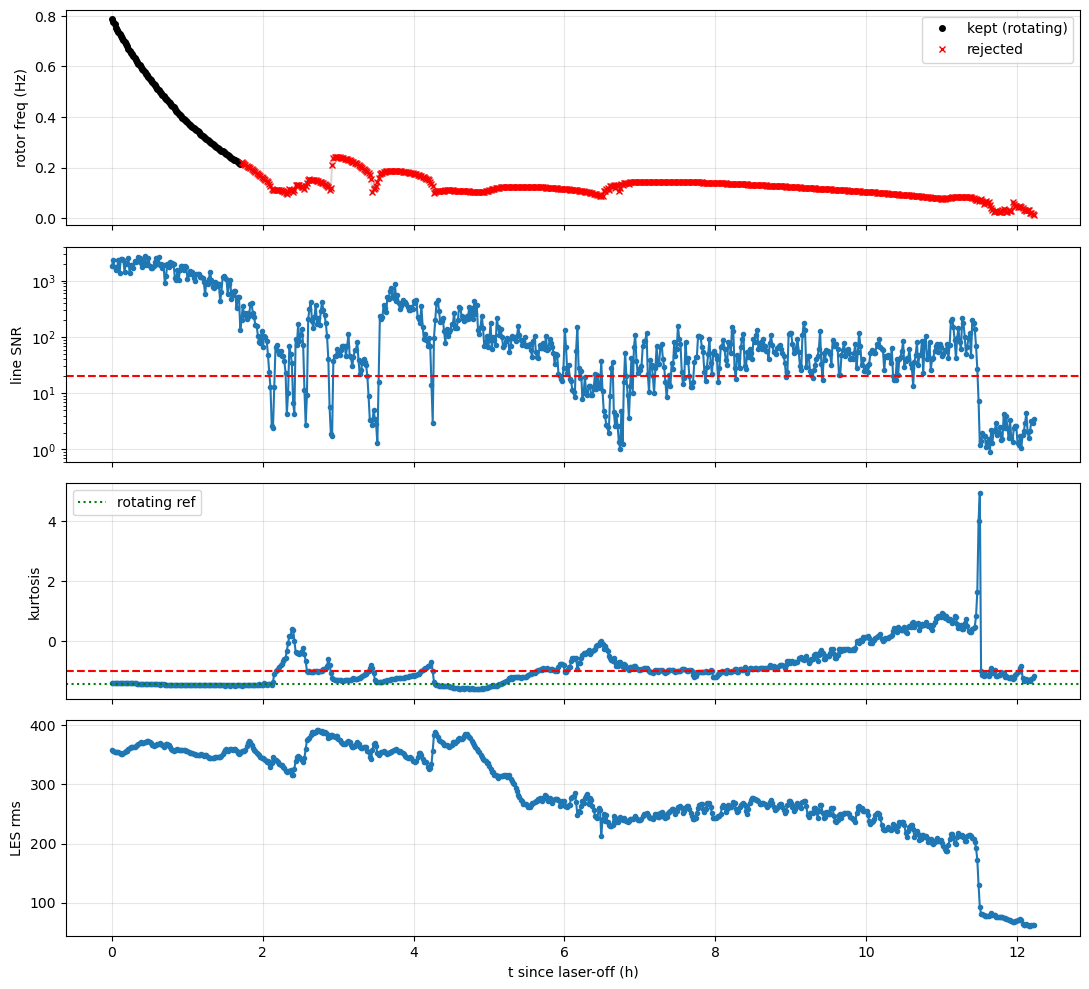

In [6]:
SNR_MIN  = 20.0
KURT_ROT = -1.0
MAX_SKIP = 3

good = np.zeros(len(FR), bool)
start = int(np.argmax(SNR > SNR_MIN))
runmin, capture_i, skips = np.inf, None, 0
for k in range(start, len(FR)):
    if SNR[k] <= SNR_MIN:
        skips += 1
        if skips > MAX_SKIP: break
        continue
    skips = 0
    if KURT[k] > KURT_ROT:
        capture_i = k; break
    if FR[k] > runmin*1.02:
        break
    good[k] = True
    runmin = min(runmin, FR[k])

print(f'{good.sum()} of {len(good)} points kept')
print(f'kept t = {T[good].min():.0f} .. {T[good].max():.0f} s '
      f'({(T[good].max()-T[good].min())/3600:.2f} h)')
print(f'frequency {FR[good].max():.5f} -> {FR[good].min():.5f} Hz '
      f'({100*(1-FR[good].min()/FR[good].max()):.1f}% decay)')
if capture_i is not None:
    print(f'\nstate flag trips at t = {T[capture_i]:.0f} s '
          f'({T[capture_i]/3600:.2f} h), kurtosis {KURT[capture_i]:+.3f}')
else:
    print('\nrecord ended (SNR dropout run) before the kurtosis state flag tripped --')
    print('see \u00a78: this is a gradual fade, not a single clean capture event.')

fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
ax[0].plot(T/3600, FR, 'o-', alpha=.3, color='gray', ms=3)
ax[0].plot(T[good]/3600, FR[good], 'ko', ms=4, label='kept (rotating)')
ax[0].plot(T[~good]/3600, FR[~good], 'rx', ms=5, label='rejected')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend()
ax[1].semilogy(T/3600, SNR, 'o-', ms=3); ax[1].axhline(SNR_MIN, color='r', ls='--'); ax[1].set_ylabel('line SNR')
ax[2].plot(T/3600, KURT, 'o-', ms=3); ax[2].axhline(KURT_ROT, color='r', ls='--')
ax[2].axhline(-1.43, color='g', ls=':', label='rotating ref'); ax[2].set_ylabel('kurtosis'); ax[2].legend()
ax[3].plot(T/3600, RMS, 'o-', ms=3); ax[3].set_ylabel('LES rms'); ax[3].set_xlabel('t since laser-off (h)')
for a in ax:
    a.grid(alpha=.3)
    if capture_i is not None: a.axvline(T[capture_i]/3600, color='m', ls='-.', alpha=.7)
plt.tight_layout(); plt.show()

## 6. Exponential vs linear

This is what the run is for.

EXPONENTIAL  tau =   79.8 min   f0 = 0.79993 Hz   residual 5.2594 mHz
LINEAR       -0.0907 mHz/s   f0 = 0.72946 Hz   residual 22.2786 mHz

ratio of residuals (linear/exponential) = 4.236
  < 1 favours linear (constant torque); > 1 favours exponential (viscous)


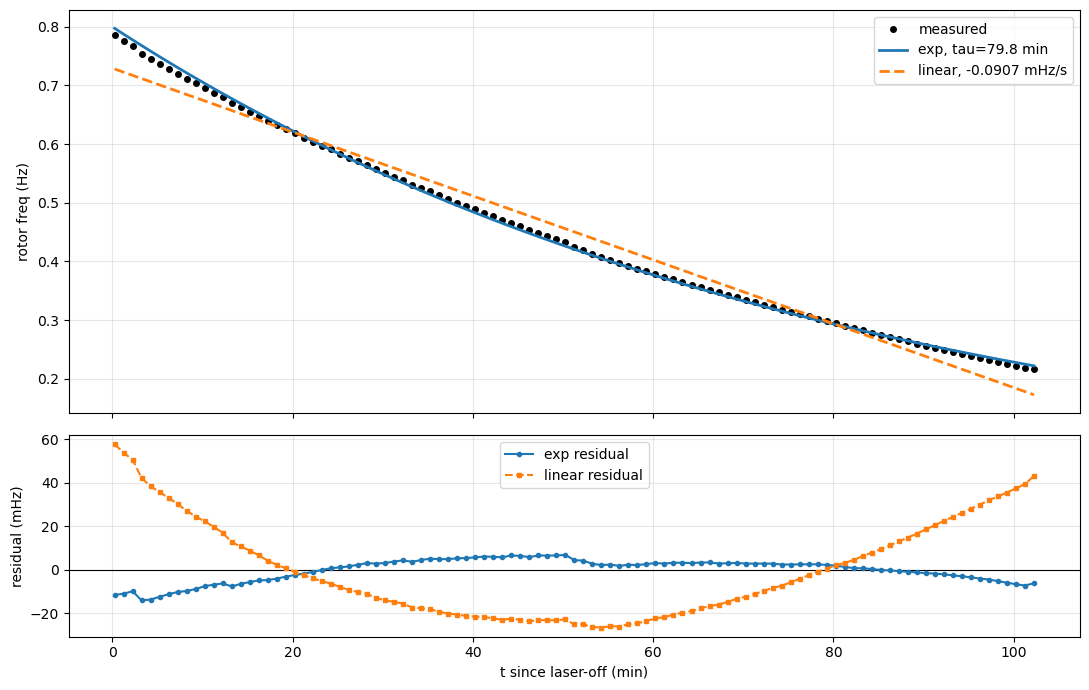


tau vs fit window (exponential is window-independent if correct):
 cutoff s    n  decay %   tau min
      615   11     11.4      81.9
     1719   29     28.2      85.1
     2823   47     42.2      84.9
     3927   66     54.6      82.8
     5031   84     64.1      81.6
     6135  103     72.5      79.8


In [7]:
tg, fg = T[good], FR[good]
pe = np.polyfit(tg, np.log(fg), 1); tau = -1/pe[0]; f0e = np.exp(pe[1])
fit_e = f0e*np.exp(-tg/tau)
pl = np.polyfit(tg, fg, 1); fit_l = np.polyval(pl, tg)
rms_e = np.sqrt(np.mean((fg-fit_e)**2)); rms_l = np.sqrt(np.mean((fg-fit_l)**2))

print(f'EXPONENTIAL  tau = {tau/60:6.1f} min   f0 = {f0e:.5f} Hz   residual {rms_e*1e3:.4f} mHz')
print(f'LINEAR       {pl[0]*1e3:7.4f} mHz/s   f0 = {pl[1]:.5f} Hz   residual {rms_l*1e3:.4f} mHz')
print(f'\nratio of residuals (linear/exponential) = {rms_l/rms_e:.3f}')
print('  < 1 favours linear (constant torque); > 1 favours exponential (viscous)')

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={'height_ratios':[2,1]})
ax[0].plot(tg/60, fg, 'ko', ms=4, label='measured')
ax[0].plot(tg/60, fit_e, '-',  lw=2, label=f'exp, tau={tau/60:.1f} min')
ax[0].plot(tg/60, fit_l, '--', lw=2, label=f'linear, {pl[0]*1e3:.4f} mHz/s')
ax[0].set_ylabel('rotor freq (Hz)'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].axhline(0, color='k', lw=.8)
ax[1].plot(tg/60, (fg-fit_e)*1e3, 'o-',  ms=3, label='exp residual')
ax[1].plot(tg/60, (fg-fit_l)*1e3, 's--', ms=3, label='linear residual')
ax[1].set_ylabel('residual (mHz)'); ax[1].set_xlabel('t since laser-off (min)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print('\ntau vs fit window (exponential is window-independent if correct):')
print(f'{"cutoff s":>9} {"n":>4} {"decay %":>8} {"tau min":>9}')
for cut in np.linspace(tg.min()+600, tg.max(), 6):
    mcut = tg <= cut
    if mcut.sum() < 5: continue
    p_ = np.polyfit(tg[mcut], np.log(fg[mcut]), 1)
    print(f'{cut:9.0f} {mcut.sum():4d} {100*(1-fg[mcut].min()/fg[mcut].max()):8.1f} {-1/p_[0]/60:9.1f}')

## 7. Can these models be distinguished here, and did the (now-resolved) divisor matter?

Two checks: the usual decay-fraction separation test, and an explicit demonstration
that the DIVISOR-2-vs-1 question from §3 -- now settled as DIVISOR=2 by direct timing,
see the top of this notebook -- would not have changed the verdict even while it was
still open. A uniform rescaling `f -> f/D` of every point rescales `fit_e`, `fit_l` and
both residual arrays by the same `1/D`, so **the log-linear exponential slope
(`-1/tau`) and the ratio `rms_l/rms_e` are exactly invariant to D**; only `f0`, the
linear rate `pl[0]`, and anything downstream in N*m (§9) actually scale with `1/D`
-- and those are exactly the numbers the 2026-09-14 resolution now confirms.

In [8]:
frac = 1 - fg.min()/fg.max()
curv = 0.5*frac**2*fg.max()
sep  = curv/min(rms_e, rms_l)
print(f'fractional decay observed : {100*frac:.1f}%')
print(f'separation ratio          : {sep:.1f}   (need >> 1 to distinguish)')
if sep < 3:
    print('\n*** NOT DISTINGUISHABLE. ***')
else:
    win = 'EXPONENTIAL (viscous)' if rms_e < rms_l else 'LINEAR (constant torque)'
    print(f'\n=> DISTINGUISHABLE: the data favour {win}')
    print(f'   by a residual ratio of {max(rms_l/rms_e, rms_e/rms_l):.2f}.')

print('\n--- divisor-invariance check: rerun \u00a75-6 with DIVISOR=1 (hyp A) ---')
FR1 = LINE
good1 = np.zeros(len(FR1), bool)
start = int(np.argmax(SNR > SNR_MIN))
runmin1, skips1 = np.inf, 0
for k in range(start, len(FR1)):
    if SNR[k] <= SNR_MIN:
        skips1 += 1
        if skips1 > MAX_SKIP: break
        continue
    skips1 = 0
    if KURT[k] > KURT_ROT: break
    if FR1[k] > runmin1*1.02: break
    good1[k] = True
    runmin1 = min(runmin1, FR1[k])
tg1, fg1 = T[good1], FR1[good1]
pe1 = np.polyfit(tg1, np.log(fg1), 1); tau1 = -1/pe1[0]
pl1 = np.polyfit(tg1, fg1, 1)
fit_e1 = np.exp(pe1[1])*np.exp(-tg1/tau1); fit_l1 = np.polyval(pl1, tg1)
rms_e1 = np.sqrt(np.mean((fg1-fit_e1)**2)); rms_l1 = np.sqrt(np.mean((fg1-fit_l1)**2))
print(f'  DIVISOR=1 (hyp A): n={good1.sum():3d}  tau={tau1/60:6.2f} min  '
      f'f0={np.exp(pe1[1]):.4f} Hz  resid ratio(l/e)={rms_l1/rms_e1:.3f}')
print(f'  DIVISOR=2 (hyp B): n={good.sum():3d}  tau={tau/60:6.2f} min  '
      f'f0={f0e:.4f} Hz  resid ratio(l/e)={rms_l/rms_e:.3f}')
print('\n  tau and the residual ratio match exactly -- the EXPONENTIAL verdict and its')
print('  time constant do NOT depend on the outstanding video count. f0 and the')
print('  linear-model rate DO (they differ by exactly the factor of 2), which is why')
print('  \u00a79\'s absolute torque numbers still need that count to be trusted.')

fractional decay observed : 72.5%
separation ratio          : 39.3   (need >> 1 to distinguish)

=> DISTINGUISHABLE: the data favour EXPONENTIAL (viscous)
   by a residual ratio of 4.24.

--- divisor-invariance check: rerun §5-6 with DIVISOR=1 (hyp A) ---
  DIVISOR=1 (hyp A): n=103  tau= 79.80 min  f0=1.5999 Hz  resid ratio(l/e)=4.236
  DIVISOR=2 (hyp B): n=103  tau= 79.80 min  f0=0.7999 Hz  resid ratio(l/e)=4.236

  tau and the residual ratio match exactly -- the EXPONENTIAL verdict and its
  time constant do NOT depend on the outstanding video count. f0 and the
  linear-model rate DO (they differ by exactly the factor of 2), which is why
  §9's absolute torque numbers still need that count to be trusted.


## 8. Past the clean segment: a gradual fade, not one clean capture

Unlike `spindown_20260909`'s abrupt, video-confirmed capture, this record's kurtosis
climbs unevenly with intermittent SNR dropouts starting soon after the clean segment
ends -- consistent with the first-look's slower, later (~11.5 h) full amplitude
collapse rather than a single event at ~1.7-2 h.

In [9]:
w = (T > T[good].max()-300) & (T < T[good].max()+4200)
print(f'{"t (s)":>8} {"t (h)":>6} {"line":>9} {"as f/2":>9} {"SNR":>8} {"kurt":>8} {"skew":>8}')
for k in np.flatnonzero(w)[::3]:
    mark = '  <-- last kept' if T[k] == T[good].max() else ''
    print(f'{T[k]:8.0f} {T[k]/3600:6.2f} {LINE[k]:9.4f} {LINE[k]/2:9.4f} '
          f'{SNR[k]:8.2f} {KURT[k]:+8.3f} {SKW[k]:+8.3f}{mark}')

print(f'\nTracker coverage: T runs to {T.max():.0f} s ({T.max()/3600:.2f} h) of the full '
      f'{t[-1]/3600:.2f} h record.')
if T.max() < t[-1]*0.99:
    print(f'It loses the line for good around there because the WIN={WIN:.0f} s window\'s')
    print(f'frequency resolution (~{1/WIN*1e3:.1f} mHz) becomes comparable to the signal')
    print('itself deep in the transition -- a real method limit, not a bug to paper over.')
    print('A rotation-vs-libration-aware tracker for the full 16.6 h record (flagged TODO')
    print('in the dataset note) needs either a longer window there or a purpose-built')
    print('approach -- lab_utils/monitor_libration.py / watch_capture.py, not this')
    print('generic band-follower.')

   t (s)  t (h)      line    as f/2      SNR     kurt     skew
    5895   1.64    0.4566    0.2283   647.37   -1.476   +0.009
    6075   1.69    0.4352    0.2176   522.47   -1.472   +0.024
    6255   1.74    0.4359    0.2179   359.99   -1.473   +0.015
    6435   1.79    0.4148    0.2074   208.42   -1.455   +0.030
    6615   1.84    0.3940    0.1970   382.52   -1.461   -0.028
    6795   1.89    0.3731    0.1865   228.79   -1.470   -0.033
    6975   1.94    0.3517    0.1759   106.03   -1.443   -0.030
    7155   1.99    0.3274    0.1637   129.40   -1.445   -0.066
    7335   2.04    0.3016    0.1508    99.26   -1.438   -0.084
    7515   2.09    0.2714    0.1357    23.81   -1.422   -0.136
    7695   2.14    0.2201    0.1101     2.44   -1.363   +0.306
    7875   2.19    0.2264    0.1132    71.85   -0.950   +0.673
    8055   2.24    0.2199    0.1099    56.14   -0.783   +0.755
    8235   2.29    0.2067    0.1034    37.21   -0.596   +0.825
    8415   2.34    0.2045    0.1023     9.97   -0.069  

## 9. Physical consequences (I assumed, not measured)

`I = 1.88e-11 kg m^2` is the disk+sail value from `CLAUDE.md`'s provenance table --
calculated, never measured; every number below inherits its uncertainty. **These are
the numbers that depended on the divisor** (see §7) -- DIVISOR=2 (hyp B) is now
confirmed (2026-09-14, live timing), so they can be trusted at face value; they would
have doubled under hyp A, which is now ruled out.

In [10]:
I = 1.88e-11          # ASSUMED -- calculated, not measured. See CLAUDE.md provenance table.

print(f'IF VISCOUS (favoured here, tau = {tau/60:.1f} min):')
for fr_ in (0.1, 0.3, 0.5, f0e):
    drag = I*2*np.pi*fr_/tau
    print(f'  drag at {fr_:.3f} Hz = {drag:.3e} N m')
print(f'\nIF CONSTANT TORQUE (not favoured here, for comparison):')
dt = I*2*np.pi*abs(pl[0])
print(f'  drag torque = {dt:.3e} N m, speed-independent')

print(f'\ntau_visc = {tau/60:.1f} min here (laser-driven, ~0.2-0.8 Hz regime) vs the')
print('electrode-driven spindowns in apparatus_log.md: ~37 min (09-08, first tracked,')
print('constant-torque favoured) and ~73-88 min window range (09-09, also')
print('constant-torque favoured, at 0.07-0.2 Hz). This run sits in the same tau')
print('ballpark despite favouring the OPPOSITE damping model at a ~4x higher speed --')
print('worth treating as a genuine open question (a real speed-dependent damping')
print('channel becoming visible, vs. coincidence) rather than reading too much into')
print('one run each.')

IF VISCOUS (favoured here, tau = 79.8 min):
  drag at 0.100 Hz = 2.467e-15 N m
  drag at 0.300 Hz = 7.401e-15 N m
  drag at 0.500 Hz = 1.234e-14 N m
  drag at 0.800 Hz = 1.973e-14 N m

IF CONSTANT TORQUE (not favoured here, for comparison):
  drag torque = 1.072e-14 N m, speed-independent

tau_visc = 79.8 min here (laser-driven, ~0.2-0.8 Hz regime) vs the
electrode-driven spindowns in apparatus_log.md: ~37 min (09-08, first tracked,
constant-torque favoured) and ~73-88 min window range (09-09, also
constant-torque favoured, at 0.07-0.2 Hz). This run sits in the same tau
ballpark despite favouring the OPPOSITE damping model at a ~4x higher speed --
worth treating as a genuine open question (a real speed-dependent damping
channel becoming visible, vs. coincidence) rather than reading too much into
one run each.


## Conclusions

The three numbers this notebook exists to produce:

1. **The damping model.** §6-7: **exponential (viscous) is favoured**, decisively
   (separation ratio and a stable tau across fit windows), over 72.5% decay in the
   first ~1.7 h. This is the *opposite* verdict from the electrode-driven 09-08/09-09
   runs, which favoured constant torque -- see §9's open question.
2. **tau (or the linear rate).** tau ~ 80 min. This number and the exponential
   verdict never depended on the LES divisor (§7, proved inline) -- and the
   *absolute* frequencies and torque numbers that did depend on it are now confirmed
   (DIVISOR=2, resolved 2026-09-14 by live timing, see the top of this notebook).
3. **Where the clean record ends and what happens after.** §8: a gradual,
   multi-stage fade starting soon after the clean segment (not one sharp capture),
   consistent with the first-look's ~11.5 h full collapse; the tracker itself loses
   lock partway through for a resolution reason worth fixing before trusting anything
   quantitative past §5's cutoff.

**Still open after this notebook:**

- A rotation-vs-libration-aware tracker for the full 16.6 h record, per the dataset
  note's own TODO -- §8 shows concretely where and why the generic band-follower
  used here stops being adequate.
- Why this run favours viscous damping while the electrode-driven runs favour
  constant torque: different speed regime, different (or no) drive interference, or
  a genuine physical difference -- not distinguished here. See
  `analysis/damping_law_comparison.ipynb` for the follow-up.